<a href="https://colab.research.google.com/github/Bryan-ing/Master-s-Degree-in-AI/blob/main/Tarea_Clase3_Distribuciones_Probabilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea Clase 3: Distribuciones de Probabilidad
## Maestria en Inteligencia Artificial

**Tiempo estimado:** 1-2 horas

### Instrucciones
Completa los ejercicios marcados con **# TU CODIGO AQUI**. Cada ejercicio tiene pistas para ayudarte.

---
## 0. Configuracion Inicial

In [2]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, binom, poisson, expon

%matplotlib inline

print('Librerias importadas')

Librerias importadas


---
## 1. Distribucion Normal

Un examen de admision tiene una distribucion normal con media mu = 500 y desviacion estandar sigma = 100.

### EJERCICIO 1: Distribucion Normal (25 puntos)

In [3]:
mu = 500
sigma = 100

# EJERCICIO 1.1: Calcula las siguientes probabilidades

# TU CODIGO AQUI
# P(X <= 500) - probabilidad de obtener menos de 500
p_menor_500 = norm.cdf(500, loc=mu, scale=sigma) #funcion de distribucipon acumulada (CDF) de una distribución normal

# P(X >= 600) - probabilidad de obtener 600 o mas
p_mayor_600 = 1 - norm.cdf(600, loc=mu, scale=sigma)

# P(400 <= X <= 600) - probabilidad de estar entre 400 y 600
p_entre_400_600 = norm.cdf(600, loc=mu, scale=sigma) - norm.cdf(400, loc=mu, scale=sigma)

print(f'Probabilidades del examen:')
print(f"  P(X <= 500)      = {p_menor_500:.4f} ({p_menor_500*100:.2f}%)")
print(f"  P(X >= 600)      = {p_mayor_600:.4f} ({p_mayor_600*100:.2f}%)")
print(f"  P(400 <= X <= 600) = {p_entre_400_600:.4f} ({p_entre_400_600*100:.2f}%)")

Probabilidades del examen:
  P(X <= 500)      = 0.5000 (50.00%)
  P(X >= 600)      = 0.1587 (15.87%)
  P(400 <= X <= 600) = 0.6827 (68.27%)


In [4]:
# EJERCICIO 1.2: Encuentra los percentiles

# TU CODIGO AQUI
# P10: puntaje que deja el 10% inferior
p10 = norm.ppf(0.1, loc=500, scale=100) #funcion para calcular los perceptiles

# P90: puntaje que deja el 90% inferior en una distribución normal la mediana es igual a la media
p90 = norm.ppf(0.9, loc=500, scale=100)

# Mediana (P50)
mediana = norm.ppf(0.5, loc=500, scale=100)

print(f'Percentiles:')
print(f"  P10 (10% inferior):  {p10:.2f} puntos")
print(f"  P50 (Mediana):       {mediana:.2f} puntos")
print(f"  P90 (10% superior):  {p90:.2f} puntos")
print(f"  Intervalo intercuartilico (P10-P90): [{p10:.0f}, {p90:.0f}]") #este ayuda a saber donde se centran la mayoria de los resultados abarcando 80%

Percentiles:
  P10 (10% inferior):  371.84 puntos
  P50 (Mediana):       500.00 puntos
  P90 (10% superior):  628.16 puntos
  Intervalo intercuartilico (P10-P90): [372, 628]


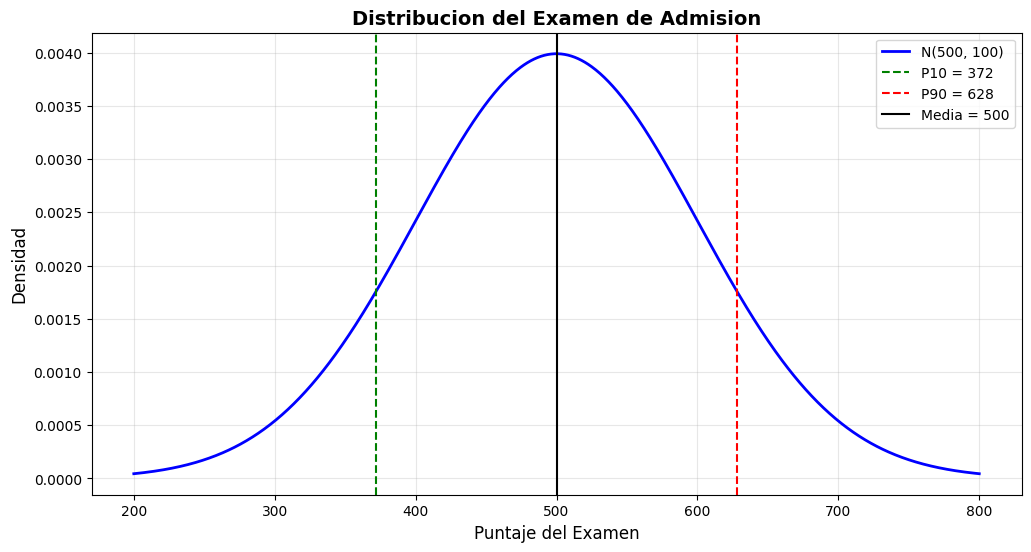

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# TU CODIGO AQUI
# 1. Genera valores x entre 200 y 800
x = np.linspace(200, 800, 1000)

# 2. Calcula la densidad de probabilidad
y = norm.pdf(x, loc=500, scale=100)

# 3. Grafica
ax.plot(x, y, 'b-', linewidth=2, label=f'N({mu}, {sigma})')

# 4. Anade lineas para percentiles
ax.axvline(x=p10, color='green', linestyle='--', label=f'P10 = {p10:.0f}')
ax.axvline(x=p90, color='red', linestyle='--', label=f'P90 = {p90:.0f}')
ax.axvline(x=mu, color='black', linestyle='-', label=f'Media = {mu}')

ax.set_xlabel('Puntaje del Examen', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Distribucion del Examen de Admision', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## 2. Distribucion Binomial

Una empresa envia 20 emails promocionales. La probabilidad de que un cliente abra el email es 0.3.

### EJERCICIO 2: Distribucion Binomial (25 puntos)

In [6]:
# Parametros
n = 20  # numero de emails
p = 0.3  # probabilidad de apertura

# EJERCICIO 2.1: Calcula las siguientes probabilidades

# TU CODIGO AQUI
# P(exactamente 5 aperturas)
p_exactamente_5 = binom.pmf(5, n=20, p=0.3)

# P(al menos 5 aperturas) = P(X >= 5)
p_al_menos_5 = 1 - binom.cdf(5, n=20, p=0.3)

# P(menos de 10 aperturas) = P(X < 10)
p_menos_10 = binom.cdf(9, n=20, p=0.3)

print(f'Probabilidades de apertura de emails:')
print(f"  P(exactamente 5)  = {p_exactamente_5:.4f} ({p_exactamente_5*100:.2f}%)")
print(f"  P(al menos 5)     = {p_al_menos_5:.4f} ({p_al_menos_5*100:.2f}%)")
print(f"  P(menos de 10)    = {p_menos_10:.4f} ({p_menos_10*100:.2f}%)")

Probabilidades de apertura de emails:
  P(exactamente 5)  = 0.1789 (17.89%)
  P(al menos 5)     = 0.5836 (58.36%)
  P(menos de 10)    = 0.9520 (95.20%)


In [7]:
# EJERCICIO 2.2: Calcula media y desviacion estandar

# TU CODIGO AQUI
media = n * p
varianza = n *p * (1-p)
std = np.sqrt(varianza) #std desviación estandar -sigma

print(f'Estadisticas:')
print(f"  Media: {media:.2f} aperturas esperadas")
print(f"  Varianza: {varianza:.2f}")
print(f"  Desv. Estandar: {std:.2f} aperturas")
print(f"  Intervalo 95%: [{media - 2*std:.1f}, {media + 2*std:.1f}] aperturas") #es una aproximación para estimar donde
#estan la mayoria de los resultados esperados,

Estadisticas:
  Media: 6.00 aperturas esperadas
  Varianza: 4.20
  Desv. Estandar: 2.05 aperturas
  Intervalo 95%: [1.9, 10.1] aperturas


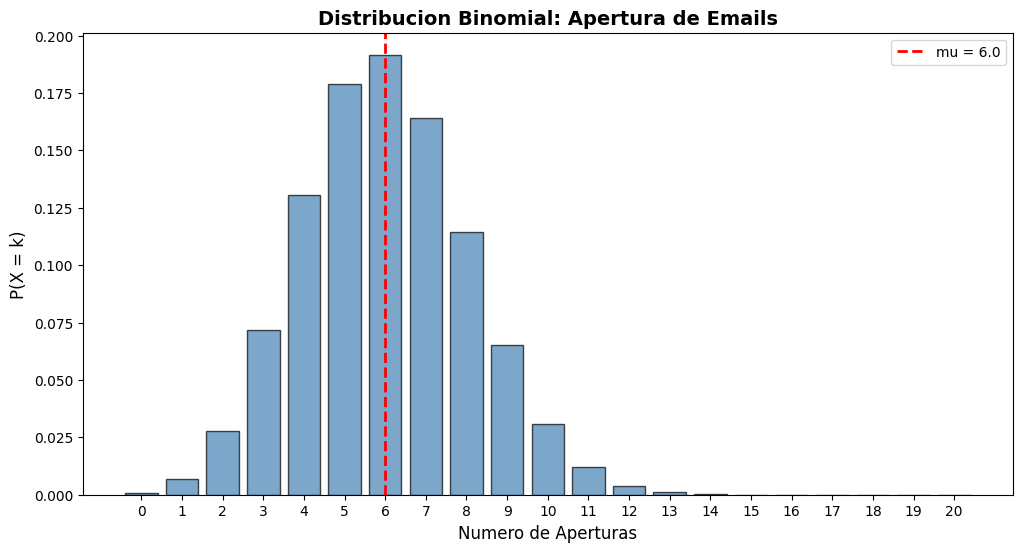

In [8]:
# EJERCICIO 2.3: Visualiza la distribucion binomial

fig, ax = plt.subplots(figsize=(12, 6))

# TU CODIGO AQUI
# 1. Genera valores k de 0 a n
k = np.arange(0, n + 1) # Asegúrate de incluir 'n' en el rango

# 2. Calcula la PMF(Funcion de masa de probabilidad)
pmf = binom.pmf(k, n=n, p=p) #probabilidad de tener k exitos en n ensayos, donde la probabilidad
#de exito de cada ensayo es p

# 3. Crea el grafico de barras
ax.bar(k, pmf, color='steelblue', alpha=0.7, edgecolor='black')

# 4. Anade linea para la media
ax.axvline(x=media, color='red', linestyle='--', linewidth=2, label=f'mu = {media:.1f}')

ax.set_xlabel('Numero de Aperturas', fontsize=12)
ax.set_ylabel('P(X = k)', fontsize=12)
ax.set_title('Distribucion Binomial: Apertura de Emails', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(k)
plt.show()

---
## 3. Distribucion de Poisson

Un servidor web recibe en promedio 5 solicitudes por minuto.

### EJERCICIO 3: Distribucion de Poisson (25 puntos)

In [16]:
# Parametro
lam = 5  # solicitudes por minuto en esta distribución recordemos que es lo mismo de lambda y media y

# EJERCICIO 3.1: Calcula probabilidades

# TU CODIGO AQUI
# P(exactamente 3 solicitudes)
p_3 = poisson.pmf(3, mu=5) #.pmf Probability Mass Function, te da la probabilidad de que la variable
#aleatoria tome un valor discreto exacto

# P(al menos 1 solicitud)
p_al_menos_1 = 1 - poisson.pmf(0, mu=5)

# P(mas de 8 solicitudes)
p_mas_8 = 1 - poisson.cdf(8, mu=5) #Cumulative Distribution Function- te da la probabilidad acumulada de que
#la variable aleatoria tome un valor menor o igual a un punto dado. se le resta 1 para que sea mayor

print(f'Probabilidades de solicitudes:')
print(f"  P(exactamente 3)  = {p_3:.4f} ({p_3*100:.2f}%)")
print(f"  P(al menos 1)     = {p_al_menos_1:.4f} ({p_al_menos_1*100:.2f}%)")
print(f"  P(mas de 8)       = {p_mas_8:.4f} ({p_mas_8*100:.2f}%)")

Probabilidades de solicitudes:
  P(exactamente 3)  = 0.1404 (14.04%)
  P(al menos 1)     = 0.9933 (99.33%)
  P(mas de 8)       = 0.0681 (6.81%)


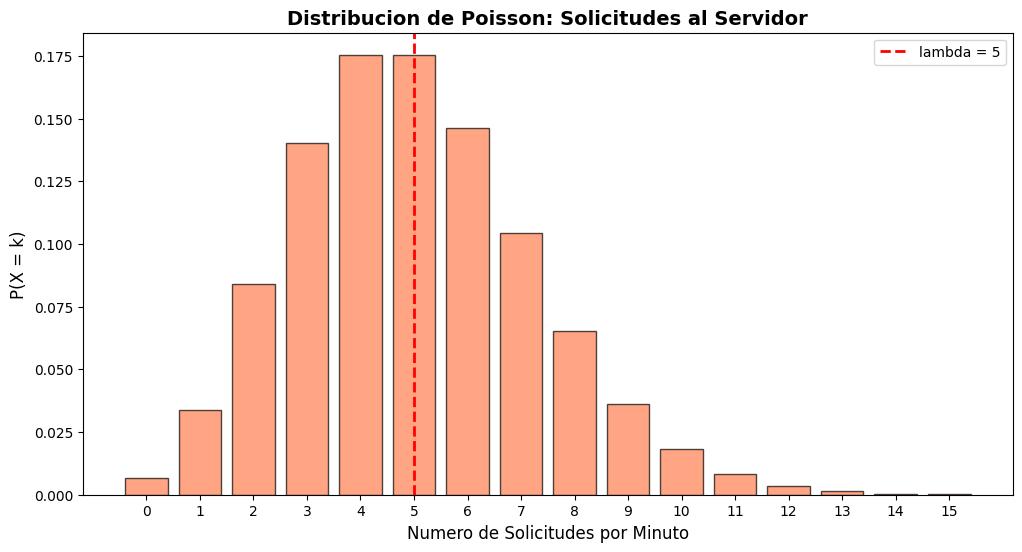

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

# TU CODIGO AQUI
# 1. Genera valores k de 0 a 15
k = np.arange(0, 16)

# 2. Calcula la PMF
pmf = poisson.pmf(k, mu=lam)

# 3. Crea el grafico de barras
ax.bar(k, pmf, color='coral', alpha=0.7, edgecolor='black') #k eje horizontal y pmf vertical

# 4. Anade linea para lambda
ax.axvline(x=lam, color='red', linestyle='--', linewidth=2, label=f'lambda = {lam}')

ax.set_xlabel('Numero de Solicitudes por Minuto', fontsize=12)
ax.set_ylabel('P(X = k)', fontsize=12)
ax.set_title('Distribucion de Poisson: Solicitudes al Servidor', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(k)
plt.show()

---
## 4. Distribucion Exponencial

El tiempo entre llegadas de clientes a una tienda sigue una distribucion exponencial con tasa lambda = 0.1 clientes por minuto (es decir, un cliente cada 10 minutos en promedio).

### EJERCICIO 4: Distribucion Exponencial (25 puntos)

In [18]:
# Parametro
lam = 0.1  # tasa (clientes por minuto) cuanto mayor es lambda mas frecuentes son los eventos
#y mas corta es la espera entre ellos.
sca=10 #inverso de lambda 1/lambda = 1/0.1 = 10
# EJERCICIO 4.1: Calcula probabilidades

# TU CODIGO AQUI
# P(tiempo <= 5 minutos)
p_menos_5 = expon.cdf(5, scale=sca) #expon.cdf función siempre es menor o igual que
#scale siempre es el inverso de lambda en spicy.stats.expon 1/lambda 1/0.1=10 ->
#->epresenta el tiempo promedio (o duración promedio) entre eventos.

# P(tiempo > 10 minutos)
p_mas_10 = 1 - expon.cdf(10, scale=sca) #tiene que ser necesariamente el parametro tal cual scale

# P(5 < tiempo <= 15 minutos)
p_5_a_15 = expon.cdf(15, scale=sca) - expon.cdf(5, scale=sca) # Corregido el orden de la resta

print(f'Probabilidades de tiempo entre llegadas:')
print(f"  P(T <= 5 min)        = {p_menos_5:.4f} ({p_menos_5*100:.2f}%)")
print(f"  P(T > 10 min)       = {p_mas_10:.4f} ({p_mas_10*100:.2f}%)")
print(f"  P(5 < T <= 15 min)   = {p_5_a_15:.4f} ({p_5_a_15*100:.2f}%)")

media = 1 / lam
print(f"  Media del tiempo entre llegadas: {media:.1f} minutos")

Probabilidades de tiempo entre llegadas:
  P(T <= 5 min)        = 0.3935 (39.35%)
  P(T > 10 min)       = 0.3679 (36.79%)
  P(5 < T <= 15 min)   = 0.3834 (38.34%)
  Media del tiempo entre llegadas: 10.0 minutos


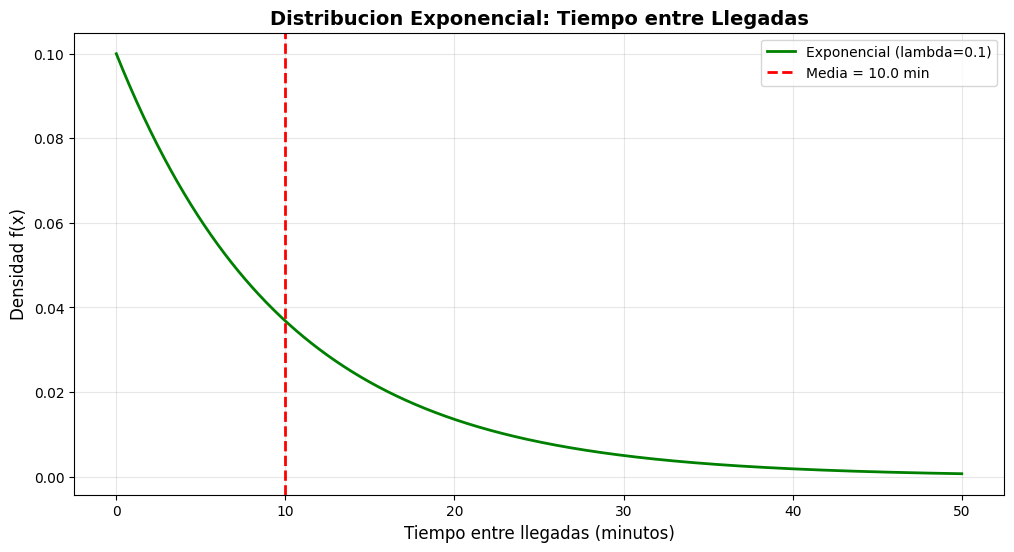

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

# TU CODIGO AQUI
# 1. Genera valores x entre 0 y 50
x = np.linspace(0, 50, 1000)

# 2. Calcula la densidad
y = expon.pdf(x, scale=sca)

# 3. Grafica
ax.plot(x, y, 'g-', linewidth=2, label=f'Exponencial (lambda={lam})') #PDF - Funcion de Densidad de Probabilidad

# 4. Anade linea para la media
ax.axvline(x=media, color='red', linestyle='--', linewidth=2, label=f'Media = {media:.1f} min')

ax.set_xlabel('Tiempo entre llegadas (minutos)', fontsize=12)
ax.set_ylabel('Densidad f(x)', fontsize=12)
ax.set_title('Distribucion Exponencial: Tiempo entre Llegadas', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## 5. Identificacion de Distribuciones

### EJERCICIO 5: Identificar la Distribucion Apropiada (20 puntos)

Para cada situacion, identifica que distribucion de probabilidad seria la mas adecuada y explica por que.

**SITUACION 5.1:** Numero de defectos en una linea de produccion por hora.

**DISTRIBUCION:** _Poisson_

**EXPLICACION:** _Debido a que se estan contando los defectos que se tienen en un tiempo determinado podemos usar la distribución de posisson es factible para aplicar debido a que se requiere el numero de defectos en una linea de producción por hora, se utiliza para contar el número de eventos (defectos) que ocurren en un intervalo fijo de tiempo o espacio cuando la tasa promedio de ocurrencia es conocida y los eventos son independientes._

**SITUACION 5.2:** Tiempo hasta que falla un componente electronico.

**DISTRIBUCION:** _Exponencial_

**EXPLICACION:** _Debido a que en un componente su tiempo de falla debe ser muy corto la distribución que mejor se acopla es la exponencial ya que esta muestraria como afecta y que tan rapido una falla en poco tiempo._

**SITUACION 5.3:** Numero de clientes que compran de 100 visitantes a una tienda online.

**DISTRIBUCION:** _Distribución binomial_

**EXPLICACION:** _Como se requiere el calculo de numero de clientes que compran en una tienda esto se considera exitos que transcurren en un determinado ensayo de 100 personas, y calcular por cada 100, cuantos son exitos, es decir cuantas personas verdaderamente compran en la tienda.  _

**SITUACION 5.4:** Errores de medicion en un instrumento de precision.

**DISTRIBUCION:** _Normal_

**EXPLICACION:** _Es la más común para modelar errores de medición aleatorios ya que se asume que los errores son simétricos alrededor del valor real (es decir, es igual de probable cometer un error por encima que por debajo del valor real) y que los errores pequeños son más probables que los errores grandes. El Teorema del Límite Central a menudo justifica el uso de la normal para la suma o el promedio de muchos pequeños errores independientes._

---
## Checklist de Entrega

- [ ] Todos los ejercicios de codigo estan completos
- [ ] Las visualizaciones se muestran correctamente
- [ ] Las preguntas de identificacion estan respondidas
- [ ] El notebook se ejecuta sin errores

**Formato de entrega:** Sube el archivo .ipynb a la plataforma del curso.